# Superstore Sales Analysis
Bu analizde ABD'deki bir perakende mağazasının satış verisi incelenmektedir.

## 1. Veriyi Yükle / Kütüphaneleri Import et

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.read_csv("train.csv")

## 2. EDA

In [2]:
df.shape

(9800, 18)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [4]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [5]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [6]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


## 3. Veri Temizleme ve İşleme

In [7]:
df["Order Date"]=pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"]=pd.to_datetime(df["Ship Date"], dayfirst=True)

In [8]:
df["Shipping Days"]=df["Ship Date"] - df["Order Date"]

In [9]:
df["Shipping Days"] = df["Shipping Days"].dt.days

In [10]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Shipping Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,7


In [11]:
df=df.drop(columns=["Row ID", "Order ID", "Customer ID", "Customer Name", "Postal Code", "Product Name","Product ID", "Country"])

In [12]:
df.columns

Index(['Order Date', 'Ship Date', 'Ship Mode', 'Segment', 'City', 'State',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Shipping Days'],
      dtype='object')

## 4. Analiz 

In [13]:
# AMAÇ: Hangi kategori ve alt kategoriler en çok satış yapıyor?
# NEDEN: Şirketin hangi ürünlerin üretileceğine yönelik daha net karar verebilmesi
kategori_bazli_toplam_satislar=df.groupby(['Category', 'Sub-Category'])["Sales"].sum()

In [14]:
type(kategori_bazli_toplam_satislar)

pandas.core.series.Series

In [15]:
df2=kategori_bazli_toplam_satislar.reset_index()

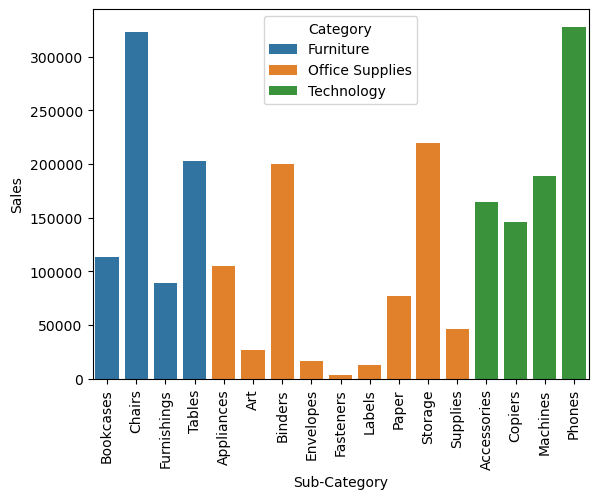

In [16]:
sns.barplot(data=df2, x="Sub-Category", y="Sales", hue="Category")
plt.tick_params("x", labelrotation=90)

In [17]:
# Ne görüyorum? Phones en yüksek satış
# Neden olabilir? Ofis ortamında insanların iletişim kurabilmesi için elzem bir ürün.  
# Şirket ne yapmalı? Fasteners ürününü gözden geçir, Phones stokunu artır.
# Fasteners ürününün toplam satış içindeki payı düşünüldüğünde bu ürünün satıştan kaldırılması gerekir. Bu ürünün üretimine harcayacağımız parayı reklam giderlerine aktarıp satış kapasitemizi genişletebiliriz.

In [18]:
# AMAÇ: Bölgelere göre satış dağılımı.
# NEDEN: Hangi bölgenin yüksek hangi bölgenin düşük satış gelirli olduğunu saptayarak, reklam faaliyetlerimizi düşük satış gelirli bölgelere yönlendirebiliriz.
sales_for_regions=df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

In [19]:
df3=sales_for_regions.reset_index()

Text(0.5, 1.0, 'Bölgelere göre Satış Gelirleri')

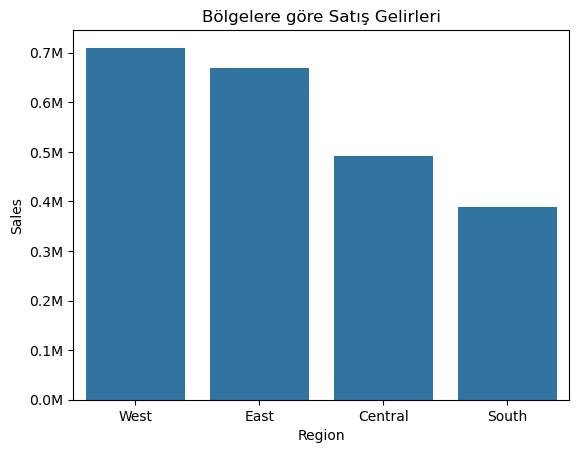

In [20]:
ax=sns.barplot(data=df3, x="Region", y="Sales")
def format_func(value,pos):
    return f"{value/1_000_000:.1f}M"
ax.yaxis.set_major_formatter(format_func)
plt.title("Bölgelere göre Satış Gelirleri")

In [21]:
# Ne görüyorum? Batı bölgesi en yüksek satış gelirine sahip bölge
# Güney bölgesinin toplam satış geliri içindeki payı yüzde 17 bu durumda Güney bölgesindeki reklam harcamalarımızı artırmamız, ürünlerimize indirimler uygulayarak
# müşteri çekmemiz şirketimiz için verimli olabilir.

In [22]:
# AMAÇ: Farklı kargo modlarında ortalama kaç günde teslim yapılıyor?
# NEDEN: Kargo modlarının teslimat süreleri arasındaki farkı gözlemlemek

In [23]:
avg_days=df.groupby("Ship Mode")["Shipping Days"].mean().sort_values(ascending=False)

In [24]:
avg_days_df=avg_days.reset_index()

In [25]:
avg_days_df.rename(columns={"Ship Mode": "Kargo Modu", "Shipping Days": "Teslimat Süresi"}, inplace=True)

Text(0.5, 1.0, 'Kargo modlarına göre Teslimat Süreleri')

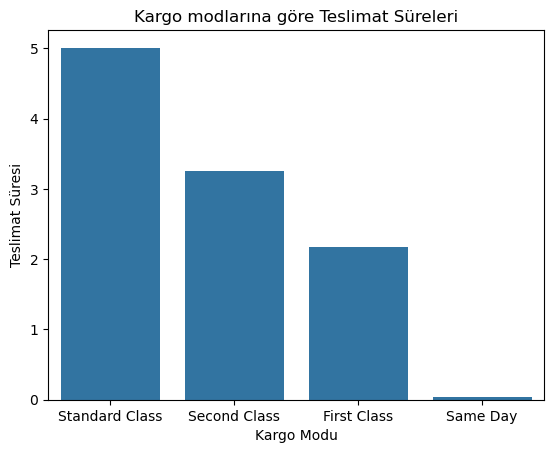

In [26]:
sns.barplot(data=avg_days_df, x="Kargo Modu", y="Teslimat Süresi")
plt.title("Kargo modlarına göre Teslimat Süreleri")

In [27]:
# Grafikten en hızlı modun "Same Day" olduğunu görüyoruz, en yavaş mod ise "Standard Class". Bu çerçevede şirketimiz, Standard Class modunda
# insan kaynaklarını artırıp, bekleme sürelerini optimize edebilir.

In [28]:
# AMAÇ: Hangi Segmentin en yüksek satış geliri getirdiğini tespit etme
# NEDEN: Düşük satış geliri getiren segmentlere yönelik yeni satış stratejileri geliştirme

In [29]:
segment_groups=df.groupby("Segment")["Sales"].agg(["sum", "mean"])

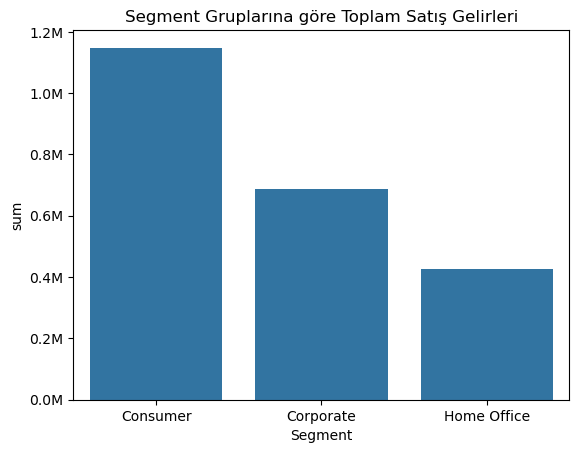

In [30]:
ax=sns.barplot(data=segment_groups, x=segment_groups.index, y=segment_groups["sum"])
plt.title("Segment Gruplarına göre Toplam Satış Gelirleri")
from matplotlib.ticker import FuncFormatter
def format_func(value, pos):
    return f"{value/1_000_000:.1f}M"
ax.yaxis.set_major_formatter(FuncFormatter(format_func))

In [31]:
print(segment_groups.at["Home Office", "sum"] / segment_groups["sum"].sum()) 

0.1879174286047309


In [32]:
# Yukarıdaki grafiğe göre Home Office Segmentine ait satış gelirlerinin payı Toplam Satış geliri içinde yalnızca %18. Şirketimiz, Home Office gibi temel ihtiyaç
# malzemelerinde yapacağı küçük indirimlerle ve pazarlama reklamlarlarıyla bu alandaki satış gelirlerini artırabilir.

In [33]:
# # AMAÇ: Bütün Segmentlerin ortalama ne kadar satış yaptığını tespit etme
# NEDEN: Segmentler arasında fark olup olmadığını saptama, fark varsa farkı kapatmaya yönelik çözüm stratejileri geliştirme.

Text(0.5, 1.0, 'Segment Gruplarına Göre ortalama Satış Gelirleri')

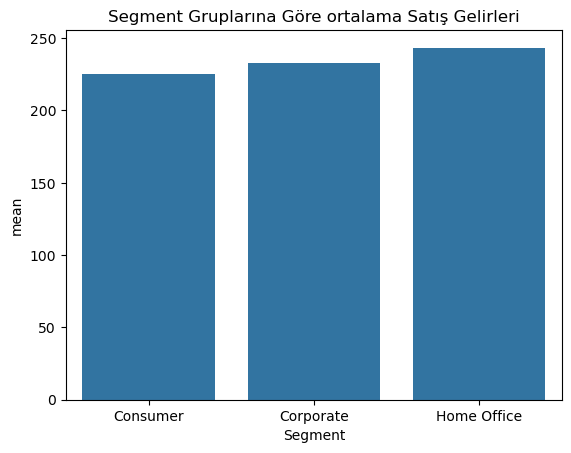

In [34]:
sns.barplot(data=segment_groups, x=segment_groups.index, y=segment_groups["mean"])
plt.title("Segment Gruplarına Göre ortalama Satış Gelirleri")

In [35]:
# "Ortalama satış açısından Home Office segmenti [243]$ ile en yüksek değere sahip. Bu Home Office müşterilerinin az ama değerli olduğu anlamına gelir. 
# Bu durumda Şirketimiz yapabilir Home Office müşterilerine yönelik yaptığı üretimlerde Sadakat Programı uygulayarak karını artırabilir."

## 5. Sonuç

* Kategorilere ait alt kategorilerdeki satış gelirleri grafiği incelendiğinde; Office Supplies kategorisine ait fasteners malzemelerinde çok az satış geliri elde ettiğimizi görüyoruz. Bu doğrultuda fasteners malzemeleri için diğer üreticilerden bizi ayıracak kampanyalar örneğin 1 alana 1 bedava kampanyası yaparak bu üründeki gelirimizi artırabiliriz.
* Bölgelere göre satış gelirleri grafiği incelendiğinde; Güney bölgesinin toplam satış geliri içindeki payının yaklaşık %17 olduğunu görüyoruz. Bu doğrultuda Şirketimiz, bu bölgede faaliyet verecek kuruluşlar açıp ve bölgenin çeşitli yerlerine reklamlar vermesiyle müşteri oranını ciddi biçimde artırabilir.
* Standard Class modunda ortalama teslimat süresi 5 gün — bu rakipler için bir tehdit oluşturabilir. Araç filosu ve lojistik kapasitesi artırılarak bu süre 3 güne indirilmesi hedeflenebilir.
* Home Office grubuna ait toplam satış geliri yalnızca toplam gelirin %18'i - bu doğrultuda ev kiralama - satışı yapan sitelere dijital reklamlar vermek bu segmentteki satış gelirimizi artırabilir.